In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df = pd.read_csv('../raw/Antioquia.csv', sep= ';')

In [3]:
df.describe()

,cliente,cantidad,preciounitario,costounitario,montoventa,montoventapesos,costoventapesos,valordescuento,unidadnegocios,centrocostos,troevendedor,obsequio,ruta,porcentajedescuento,margenpesos,porcentajemargen,zona
count,"944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00","944,178.00"
mean,"364,183,891.32",25.56,"4,038.94","1,770.90","43,593.38","43,593.38","19,136.27","1,565.44",1.00,23.33,"480,324,198.76",0.00,"1,370.83",0.01,"24,457.11",0.55,148.54
std,"489,099,350.12",99.51,"8,293.46","4,134.85","125,544.07","125,544.07","56,972.32","17,935.73",0.00,53.04,"492,683,284.53",0.00,126.30,0.03,"72,421.00",0.15,51.53
min,"295,436.00","-2,880.00",0.00,181.70,"-5,269,495.51","-5,269,495.51","-2,193,623.42","-300,630.15",1.00,1.00,"9,901.00",0.00,"1,301.00",0.00,"-3,075,872.09",-22.89,14.00
25%,"32,304,581.00",5.00,882.35,463.17,"16,806.80","16,806.80","7,679.84",0.00,1.00,1.00,"71,264,390.00",0.00,"1,325.00",0.00,"8,686.57",0.47,107.00
50%,"70,662,639.00",12.00,"2,352.94",938.38,"25,210.20","25,210.20","10,623.73",0.00,1.00,1.00,"88,274,428.00",0.00,"1,347.00",0.00,"13,943.53",0.56,115.00
75%,"901,624,533.00",25.00,"3,781.51","1,574.80","39,495.80","39,495.80","17,711.62",0.00,1.00,4.00,"1,036,650,810.00",0.00,"1,414.00",0.00,"25,440.35",0.63,204.00
max,"10,483,221,957.00","14,400.00","1,651,818.33","1,022,250.31","36,847,040.40","36,847,040.40","14,843,385.95","5,505,879.60",1.00,176.00,"1,152,211,739.00",0.00,"9,999.00",0.97,"22,003,654.45",0.81,210.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944178 entries, 0 to 944177
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   factura              944178 non-null  object 
 1   cliente              944178 non-null  int64  
 2   nombrecliente        944178 non-null  object 
 3   tipocliente          944178 non-null  object 
 4   fechafactura         944178 non-null  object 
 5   referencia           944178 non-null  object 
 6   nombrereferencia     944178 non-null  object 
 7   cantidad             944178 non-null  float64
 8   preciounitario       944178 non-null  float64
 9   costounitario        944178 non-null  float64
 10  montoventa           944178 non-null  float64
 11  montoventapesos      944178 non-null  float64
 12  costoventapesos      944178 non-null  float64
 13  valordescuento       944178 non-null  float64
 14  unidadnegocios       944178 non-null  int64  
 15  centrocostos     

## Cambio de tipos de columnas

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944178 entries, 0 to 944177
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   factura              944178 non-null  object 
 1   cliente              944178 non-null  int64  
 2   nombrecliente        944178 non-null  object 
 3   tipocliente          944178 non-null  object 
 4   fechafactura         944178 non-null  object 
 5   referencia           944178 non-null  object 
 6   nombrereferencia     944178 non-null  object 
 7   cantidad             944178 non-null  float64
 8   preciounitario       944178 non-null  float64
 9   costounitario        944178 non-null  float64
 10  montoventa           944178 non-null  float64
 11  montoventapesos      944178 non-null  float64
 12  costoventapesos      944178 non-null  float64
 13  valordescuento       944178 non-null  float64
 14  unidadnegocios       944178 non-null  int64  
 15  centrocostos     

In [6]:
df['fechafactura']=pd.to_datetime(df['fechafactura'])
df['cliente']=df['cliente'].astype(int)

## Agrupacion de clientes

In [7]:
#Formula para la moda

def obtener_moda(serie):
    return serie.mode()[0]

last_date = df['fechafactura'].max()
df_clientes = df.groupby('cliente').agg(
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura', (lambda x:(last_date - x.max()).days)),
    ticket_promedio = ('montoventapesos', 'mean'),   
    ticket = ('montoventapesos', 'sum'),
    referencias_unicas = ('referencia','nunique'),
    margen_promeido = ('margenpesos', 'mean'),
    margen = ('margenpesos', 'sum'),
    avg_descuento = ('porcentajedescuento','mean')
    
).reset_index(drop= False)

df_clientes['cl_value'] = df_clientes['frecuencia'] * df_clientes['ticket_promedio']

df_lineas = df.groupby('cliente')['lineatat'].agg(obtener_moda)
df_clientes = pd.merge(df_clientes, df_lineas, on= 'cliente', how= 'inner')

df_marcas = df.groupby('cliente')['tro_e_marca'].agg(obtener_moda)
df_clientes = pd.merge(df_clientes, df_marcas, on= 'cliente', how= 'inner')

df_clientes = df_clientes.rename(columns= {'tro_e_marca':'marca_favorita',
                                           'lineatat':'linea_favorita'})
df_clientes.head()

,cliente,frecuencia,recencia,ticket_promedio,ticket,referencias_unicas,margen_promeido,margen,avg_descuento,cl_value,linea_favorita,marca_favorita
0,295436,21,26,"18,500.83","1,239,555.80",24,"10,391.03","696,199.31",0.00,"388,517.49",OTROS,GP
1,356663,11,403,"27,042.66","703,109.06",13,"14,137.01","367,562.19",0.00,"297,469.22",MANGANESO,TRONEX
2,387708,6,310,"22,260.95","267,131.44",4,"11,583.23","138,998.71",0.00,"133,565.72",MANGANESO,TRONEX
3,492108,2,662,"22,092.40","66,277.20",2,"12,850.31","38,550.92",0.00,"44,184.80",ENCENDEDORES,SL
4,506032,5,456,"13,271.72","79,630.32",4,"7,144.44","42,866.62",0.00,"66,358.60",ENCENDEDORES,SL


In [8]:
display(df_clientes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22694 entries, 0 to 22693
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente             22694 non-null  int64  
 1   frecuencia          22694 non-null  int64  
 2   recencia            22694 non-null  int64  
 3   ticket_promedio     22694 non-null  float64
 4   ticket              22694 non-null  float64
 5   referencias_unicas  22694 non-null  int64  
 6   margen_promeido     22694 non-null  float64
 7   margen              22694 non-null  float64
 8   avg_descuento       22694 non-null  float64
 9   cl_value            22694 non-null  float64
 10  linea_favorita      22694 non-null  object 
 11  marca_favorita      22694 non-null  object 
dtypes: float64(6), int64(4), object(2)
memory usage: 2.1+ MB


None

# Agrupacion de productos

In [9]:
df_productos= df.groupby(['referencia', 'nombrereferencia']).agg(
    cantidad = ('cantidad','sum'),
    ventas = ('montoventapesos', 'sum'),
    avg_descuento = ('porcentajedescuento', 'mean')
).reset_index()

df_productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   referencia        416 non-null    object 
 1   nombrereferencia  416 non-null    object 
 2   cantidad          416 non-null    float64
 3   ventas            416 non-null    float64
 4   avg_descuento     416 non-null    float64
dtypes: float64(3), object(2)
memory usage: 16.4+ KB


In [10]:
df_productos.sort_values(by=['cantidad','ventas'], ascending=False).head()

,referencia,nombrereferencia,cantidad,ventas,avg_descuento
319,TRAAR6EHDR1,PILA MANGANESO TRONEX EHD AA RISTRA X1,"7,466,025.00","5,960,925,317.50",0.01
314,TRAAAR03EHDBLK,PILA MANGANESO TRONEX EHD AAA BULK,"4,455,685.00","3,528,561,219.66",0.01
329,TRDR20RJBLK180,PILA MANGANESO TRONEX ROJA D BULK 180,"1,859,737.00","3,833,411,369.15",0.01
317,TRAALR6ALB2,PILA ALCALINA TRONEX AA BLISTER X2,"1,230,701.00","4,340,016,059.68",0.01
315,TRAAAR03EHDBLK,PILA MANGANESO TRONEX EHD J AAA BULK,"1,048,183.00","877,005,494.27",0.01


## Distribucion ordinaria

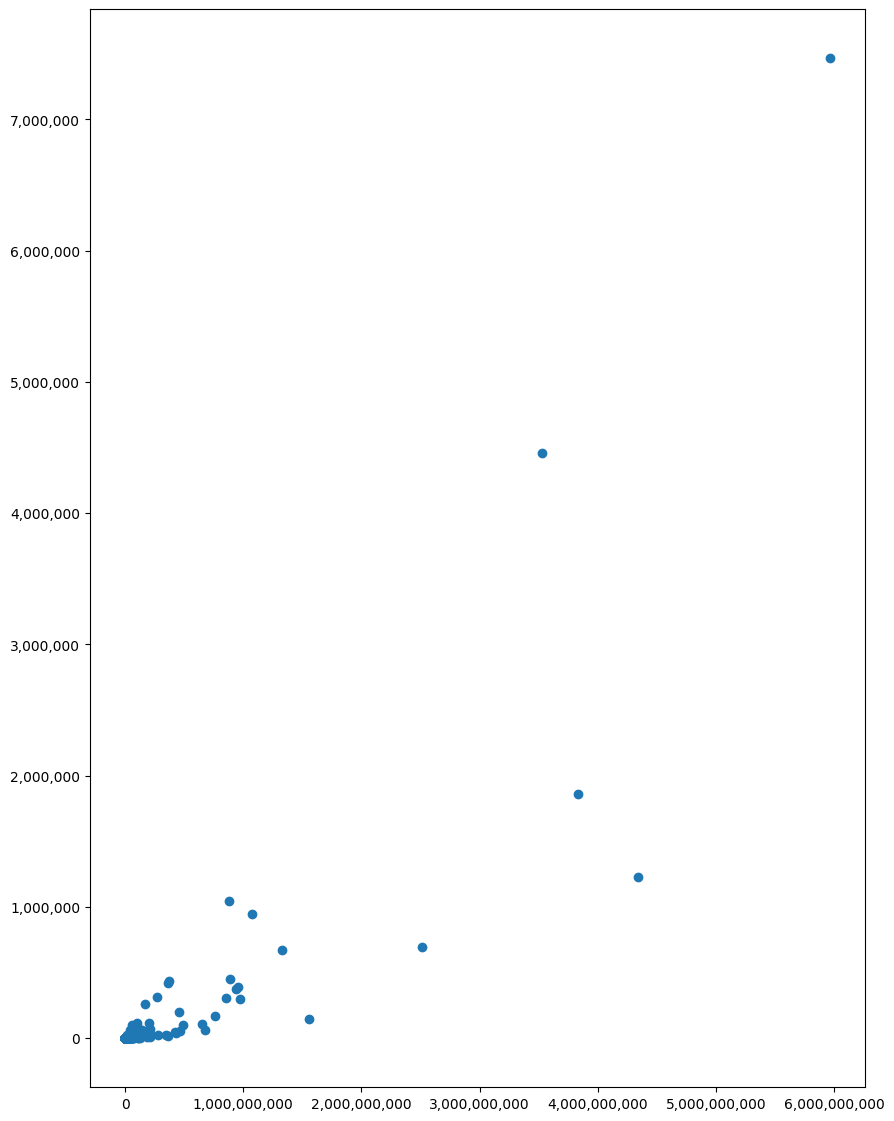

In [11]:
plt.figure(figsize=(10,14))

plt.scatter(x= df_productos['ventas'], y=df_productos['cantidad'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))

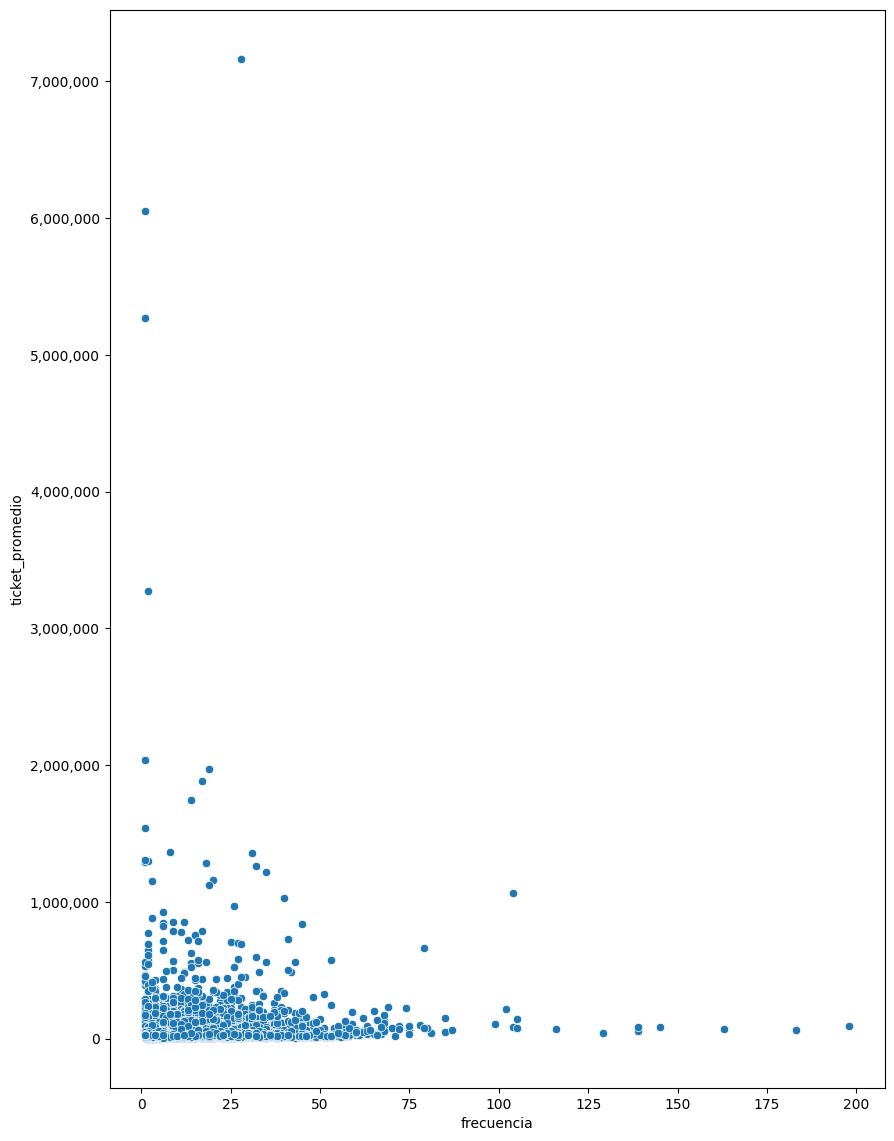

In [12]:
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10,14))

sns.scatterplot(data= df_clientes, x='frecuencia', y='ticket_promedio')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Clientes

In [13]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22694 entries, 0 to 22693
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente             22694 non-null  int64  
 1   frecuencia          22694 non-null  int64  
 2   recencia            22694 non-null  int64  
 3   ticket_promedio     22694 non-null  float64
 4   ticket              22694 non-null  float64
 5   referencias_unicas  22694 non-null  int64  
 6   margen_promeido     22694 non-null  float64
 7   margen              22694 non-null  float64
 8   avg_descuento       22694 non-null  float64
 9   cl_value            22694 non-null  float64
 10  linea_favorita      22694 non-null  object 
 11  marca_favorita      22694 non-null  object 
dtypes: float64(6), int64(4), object(2)
memory usage: 2.1+ MB


### Eliminando clietnes nulos

In [14]:
df_clientes_nulos=df_clientes[df_clientes['ticket_promedio']<=0]
df_clientes =df_clientes[df_clientes['ticket_promedio']>0]

In [15]:
df_clientes_nulos

,cliente,frecuencia,recencia,ticket_promedio,ticket,referencias_unicas,margen_promeido,margen,avg_descuento,cl_value,linea_favorita,marca_favorita
5648,30390388,2,442,0.00,0.00,2,-0.14,-0.55,0.00,0.00,BOMBILLAS,SB
6038,32328118,2,582,0.00,0.00,6,0.00,0.00,0.00,0.00,ALKALINAS,TRONEX
13253,71110678,2,527,0.00,0.00,5,-0.02,-0.24,0.00,0.00,MANGANESO,TRONEX
13895,71531910,2,453,0.00,0.00,2,-0.01,-0.03,0.03,0.00,MANGANESO,TRONEX
14002,71614501,2,556,0.00,0.00,2,-0.26,-1.05,0.00,0.00,MANGANESO,TRONEX
15948,98699836,5,212,0.00,0.00,7,0.00,0.00,0.00,0.00,OTROS,GP
16407,900795696,2,606,0.00,0.00,1,0.00,0.00,0.00,0.00,ENCENDEDORES,CP
16587,901256014,3,729,0.00,0.00,2,0.00,0.00,0.00,0.00,ENCENDEDORES,SL
16589,901256880,3,682,-408.22,"-3,674.01",4,-0.00,-0.00,0.00,"-1,224.67",MANGANESO,TRONEX
16675,901372776,4,605,-0.00,-0.00,11,-0.01,-0.42,0.00,-0.00,MANGANESO,TRONEX


### Dividiendo los clientes inactivos de los clientes activos

In [16]:
df_inactivos = df_clientes[(df_clientes['frecuencia']>=1) & (df_clientes['recencia']>84)]

df_activos = df_clientes[(df_clientes['frecuencia']>=1) & (df_clientes['recencia']<=84)]

display(df_inactivos.count() + df_activos.count())
display(df_activos.describe().T)
display(df_inactivos.describe().T)

cliente               22676
frecuencia            22676
recencia              22676
ticket_promedio       22676
ticket                22676
referencias_unicas    22676
margen_promeido       22676
margen                22676
avg_descuento         22676
cl_value              22676
linea_favorita        22676
marca_favorita        22676
dtype: int64

,count,mean,std,min,25%,50%,75%,max
cliente,"15,988.00","321,076,613.39","475,917,132.36","295,436.00","26,323,426.00","70,137,089.50","901,464,556.50","10,351,286,301.00"
frecuencia,"15,988.00",18.49,10.62,1.00,11.00,17.00,25.00,198.00
recencia,"15,988.00",24.02,20.56,0.00,10.00,17.00,31.00,82.00
ticket_promedio,"15,988.00","36,284.83","80,511.36","2,694.76","18,896.02","24,874.85","34,539.81","7,165,034.54"
ticket,"15,988.00","2,333,183.81","9,176,947.34","7,250.00","455,125.15","920,434.04","1,963,719.65","750,728,142.07"
referencias_unicas,"15,988.00",13.44,9.05,1.00,7.00,11.00,18.00,83.00
margen_promeido,"15,988.00","20,282.44","49,232.66",590.10,"10,088.04","13,653.33","19,857.10","4,761,734.11"
margen,"15,988.00","1,312,107.35","4,917,988.07","1,740.09","241,383.04","498,051.25","1,104,260.23","375,930,174.79"
avg_descuento,"15,988.00",0.01,0.01,0.00,0.00,0.00,0.01,0.15
cl_value,"15,988.00","719,375.46","2,337,418.79","2,694.76","251,548.50","437,562.04","731,452.50","200,620,967.14"


,count,mean,std,min,25%,50%,75%,max
cliente,"6,688.00","366,689,911.82","524,031,560.69","356,663.00","32,392,699.25","70,384,841.00","1,002,829,735.75","10,483,221,957.00"
frecuencia,"6,688.00",6.85,5.76,1.00,2.00,5.00,10.00,53.00
recencia,"6,688.00",336.47,205.48,85.00,149.00,289.00,515.00,736.00
ticket_promedio,"6,688.00","35,526.33","123,611.81",505.02,"16,735.76","21,868.72","30,253.11","6,050,448.00"
ticket,"6,688.00","576,700.36","2,439,331.80","2,200.00","93,568.81","228,869.80","534,572.39","155,754,642.27"
referencias_unicas,"6,688.00",7.12,5.79,1.00,3.00,6.00,9.00,65.00
margen_promeido,"6,688.00","19,417.10","69,474.72",278.64,"8,564.74","11,640.19","16,979.56","3,177,318.57"
margen,"6,688.00","316,072.49","1,241,030.34",424.19,"48,159.80","121,466.82","289,291.97","71,851,726.80"
avg_descuento,"6,688.00",0.00,0.01,0.00,0.00,0.00,0.00,0.15
cl_value,"6,688.00","230,741.49","599,353.84","1,218.49","50,227.30","120,459.29","255,094.30","30,668,348.54"


### trabajando con clientes en diferentes sectores

Los clientes son enteramente aplastados principalmente por ese unico cliente que me realiza compras de 7millones en promedio

In [17]:
df_activos.sort_values(by='ticket_promedio', ascending= False)
df_activos.describe().T

,count,mean,std,min,25%,50%,75%,max
cliente,"15,988.00","321,076,613.39","475,917,132.36","295,436.00","26,323,426.00","70,137,089.50","901,464,556.50","10,351,286,301.00"
frecuencia,"15,988.00",18.49,10.62,1.00,11.00,17.00,25.00,198.00
recencia,"15,988.00",24.02,20.56,0.00,10.00,17.00,31.00,82.00
ticket_promedio,"15,988.00","36,284.83","80,511.36","2,694.76","18,896.02","24,874.85","34,539.81","7,165,034.54"
ticket,"15,988.00","2,333,183.81","9,176,947.34","7,250.00","455,125.15","920,434.04","1,963,719.65","750,728,142.07"
referencias_unicas,"15,988.00",13.44,9.05,1.00,7.00,11.00,18.00,83.00
margen_promeido,"15,988.00","20,282.44","49,232.66",590.10,"10,088.04","13,653.33","19,857.10","4,761,734.11"
margen,"15,988.00","1,312,107.35","4,917,988.07","1,740.09","241,383.04","498,051.25","1,104,260.23","375,930,174.79"
avg_descuento,"15,988.00",0.01,0.01,0.00,0.00,0.00,0.01,0.15
cl_value,"15,988.00","719,375.46","2,337,418.79","2,694.76","251,548.50","437,562.04","731,452.50","200,620,967.14"


In [18]:
df_nuevos = df_activos[df_activos['frecuencia']==1]
df_fieles = df_activos[(df_activos['frecuencia']>=2)]

In [19]:
print('CLientes fieles')
display(df_fieles.describe().T)
print('Clientes nuevos')
display(df_nuevos.info())

CLientes fieles


,count,mean,std,min,25%,50%,75%,max
cliente,"15,699.00","317,034,420.95","474,502,334.00","295,436.00","25,635,046.50","70,130,670.00","901,371,473.00","10,351,286,301.00"
frecuencia,"15,699.00",18.82,10.44,2.00,12.00,18.00,25.00,198.00
recencia,"15,699.00",23.89,20.48,0.00,10.00,17.00,31.00,82.00
ticket_promedio,"15,699.00","36,247.47","80,863.81","5,976.92","18,937.33","24,894.97","34,544.61","7,165,034.54"
ticket,"15,699.00","2,373,709.17","9,256,051.20","18,277.48","473,533.17","939,641.18","1,988,427.42","750,728,142.07"
referencias_unicas,"15,699.00",13.62,9.02,1.00,7.00,11.00,18.00,83.00
margen_promeido,"15,699.00","20,246.53","49,440.03","1,831.72","10,106.33","13,648.74","19,854.32","4,761,734.11"
margen,"15,699.00","1,334,830.85","4,960,110.11","7,092.77","251,791.33","509,942.75","1,123,517.74","375,930,174.79"
avg_descuento,"15,699.00",0.01,0.01,0.00,0.00,0.00,0.01,0.15
cl_value,"15,699.00","731,912.98","2,356,979.24","11,953.84","261,058.68","444,641.97","739,393.75","200,620,967.14"


Clientes nuevos
<class 'pandas.core.frame.DataFrame'>
Index: 289 entries, 111 to 22679
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente             289 non-null    int64  
 1   frecuencia          289 non-null    int64  
 2   recencia            289 non-null    int64  
 3   ticket_promedio     289 non-null    float64
 4   ticket              289 non-null    float64
 5   referencias_unicas  289 non-null    int64  
 6   margen_promeido     289 non-null    float64
 7   margen              289 non-null    float64
 8   avg_descuento       289 non-null    float64
 9   cl_value            289 non-null    float64
 10  linea_favorita      289 non-null    object 
 11  marca_favorita      289 non-null    object 
dtypes: float64(6), int64(4), object(2)
memory usage: 29.4+ KB


None

### Distribucion de los datos

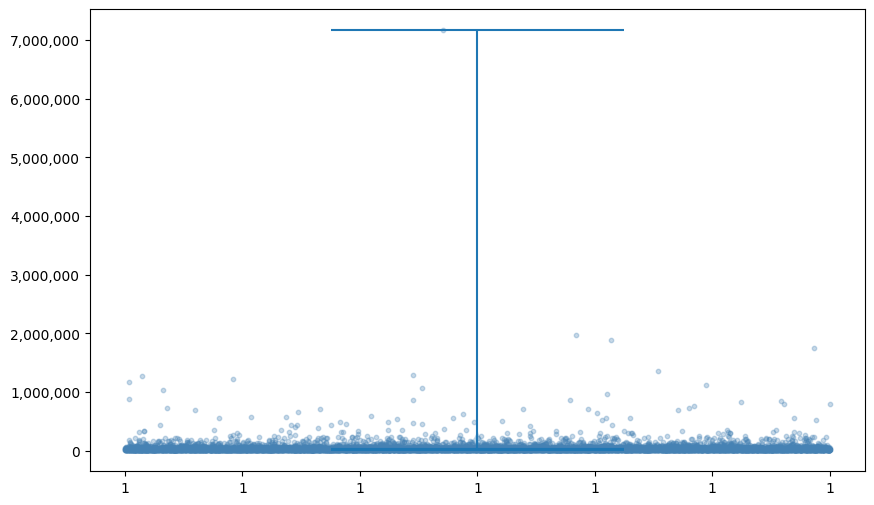

In [20]:
plt.figure(figsize= (10,6))

plt.violinplot(df_fieles['ticket_promedio'], showmeans=True, showmedians=True)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
jitter = np.random.uniform(0.7, 1.3, size=len(df_fieles))
plt.scatter(jitter, 
            df_fieles['ticket_promedio'], 
            alpha=0.3, 
            s=10, 
            color='steelblue')

# Separacion

## Analisis de cuantiles

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos los cuantiles que queremos explorar
cuantiles = np.arange(0.01, 1.01, 0.01)  # Del 5% al 100%, de 5 en 5

# Calculamos los cuantiles para ambas variables
tabla_cuantiles = pd.DataFrame({
    'cuantil': [f'{int(q*100)}%' for q in cuantiles],
    'frecuencia': [df_fieles['frecuencia'].quantile(q) for q in cuantiles],
    'ticket_promedio': [df_fieles['ticket_promedio'].quantile(q) for q in cuantiles]
})

print(tabla_cuantiles.to_string(index=False))


cuantil  frecuencia  ticket_promedio
     1%        2.00        10,387.42
     2%        3.00        11,725.64
     3%        3.00        12,560.21
     4%        4.00        13,174.31
     5%        4.00        13,651.24
     6%        5.00        14,076.65
     6%        5.00        14,488.24
     8%        6.00        14,877.51
     9%        6.00        15,199.18
    10%        7.00        15,446.82
    11%        7.00        15,750.73
    12%        8.00        16,007.32
    13%        8.00        16,255.55
    14%        8.00        16,528.92
    15%        9.00        16,737.41
    16%        9.00        16,928.18
    17%        9.00        17,143.07
    18%        9.00        17,366.84
    19%       10.00        17,601.32
    20%       10.00        17,818.42
    21%       10.00        18,053.65
    22%       11.00        18,267.10
    23%       11.00        18,486.69
    24%       11.00        18,697.60
    25%       12.00        18,937.33
    26%       12.00        19,165.52
 

## Segmantacion de clientes con base en los cuantiles

In [22]:
df_bajo = df_fieles[df_fieles['ticket_promedio']<= df_fieles['ticket_promedio'].quantile(0.45)]

df_medio = df_fieles[(df_fieles['ticket_promedio']>df_fieles['ticket_promedio'].quantile(0.45))&(df_fieles['ticket_promedio']<=df_fieles['ticket_promedio'].quantile(0.75))]

df_alto = df_fieles[(df_fieles['ticket_promedio']>df_fieles['ticket_promedio'].quantile(0.75))&(df_fieles['ticket_promedio']<=df_fieles['ticket_promedio'].quantile(0.90))]

df_premium = df_fieles[(df_fieles['ticket_promedio']>df_fieles['ticket_promedio'].quantile(0.90))&(df_fieles['ticket_promedio']<=df_fieles['ticket_promedio'].quantile(0.97))]

df_vip_premium = df_fieles[(df_fieles['ticket_promedio']>df_fieles['ticket_promedio'].quantile(0.97))&(df_fieles['ticket_promedio']<df_fieles['ticket_promedio'].quantile(0.9997))]

df_outlier = df_fieles[(df_fieles['ticket_promedio']>=df_fieles['ticket_promedio'].quantile(0.9997))]

In [23]:
print(f"cantidad de clientes en df_bajo {len(df_bajo)} ")
print(f"cantidad de clientes en df_medio {len(df_medio)}")
print(f"cantidad de clientes en df_alto {len(df_alto)}")
print(f"cantidad de clientes en df_premium {len(df_premium)}")
print(f"cantidad de clientes en df_vip_premium {len(df_vip_premium)}")
print(f"cantidad de clientes en df_outlier {len(df_outlier)}")
print('------------------------')
display(df_bajo.count()+df_medio.count()+df_alto.count()+df_premium.count()+df_vip_premium.count()+df_outlier.count())

cantidad de clientes en df_bajo 7065 
cantidad de clientes en df_medio 4709
cantidad de clientes en df_alto 2355
cantidad de clientes en df_premium 1099
cantidad de clientes en df_vip_premium 466
cantidad de clientes en df_outlier 5
------------------------


cliente               15699
frecuencia            15699
recencia              15699
ticket_promedio       15699
ticket                15699
referencias_unicas    15699
margen_promeido       15699
margen                15699
avg_descuento         15699
cl_value              15699
linea_favorita        15699
marca_favorita        15699
dtype: int64

### Grafico de densidad de l distribucion de cada uno de los segmentos

Text(0.95, 0.95, 'Clientes: 5')

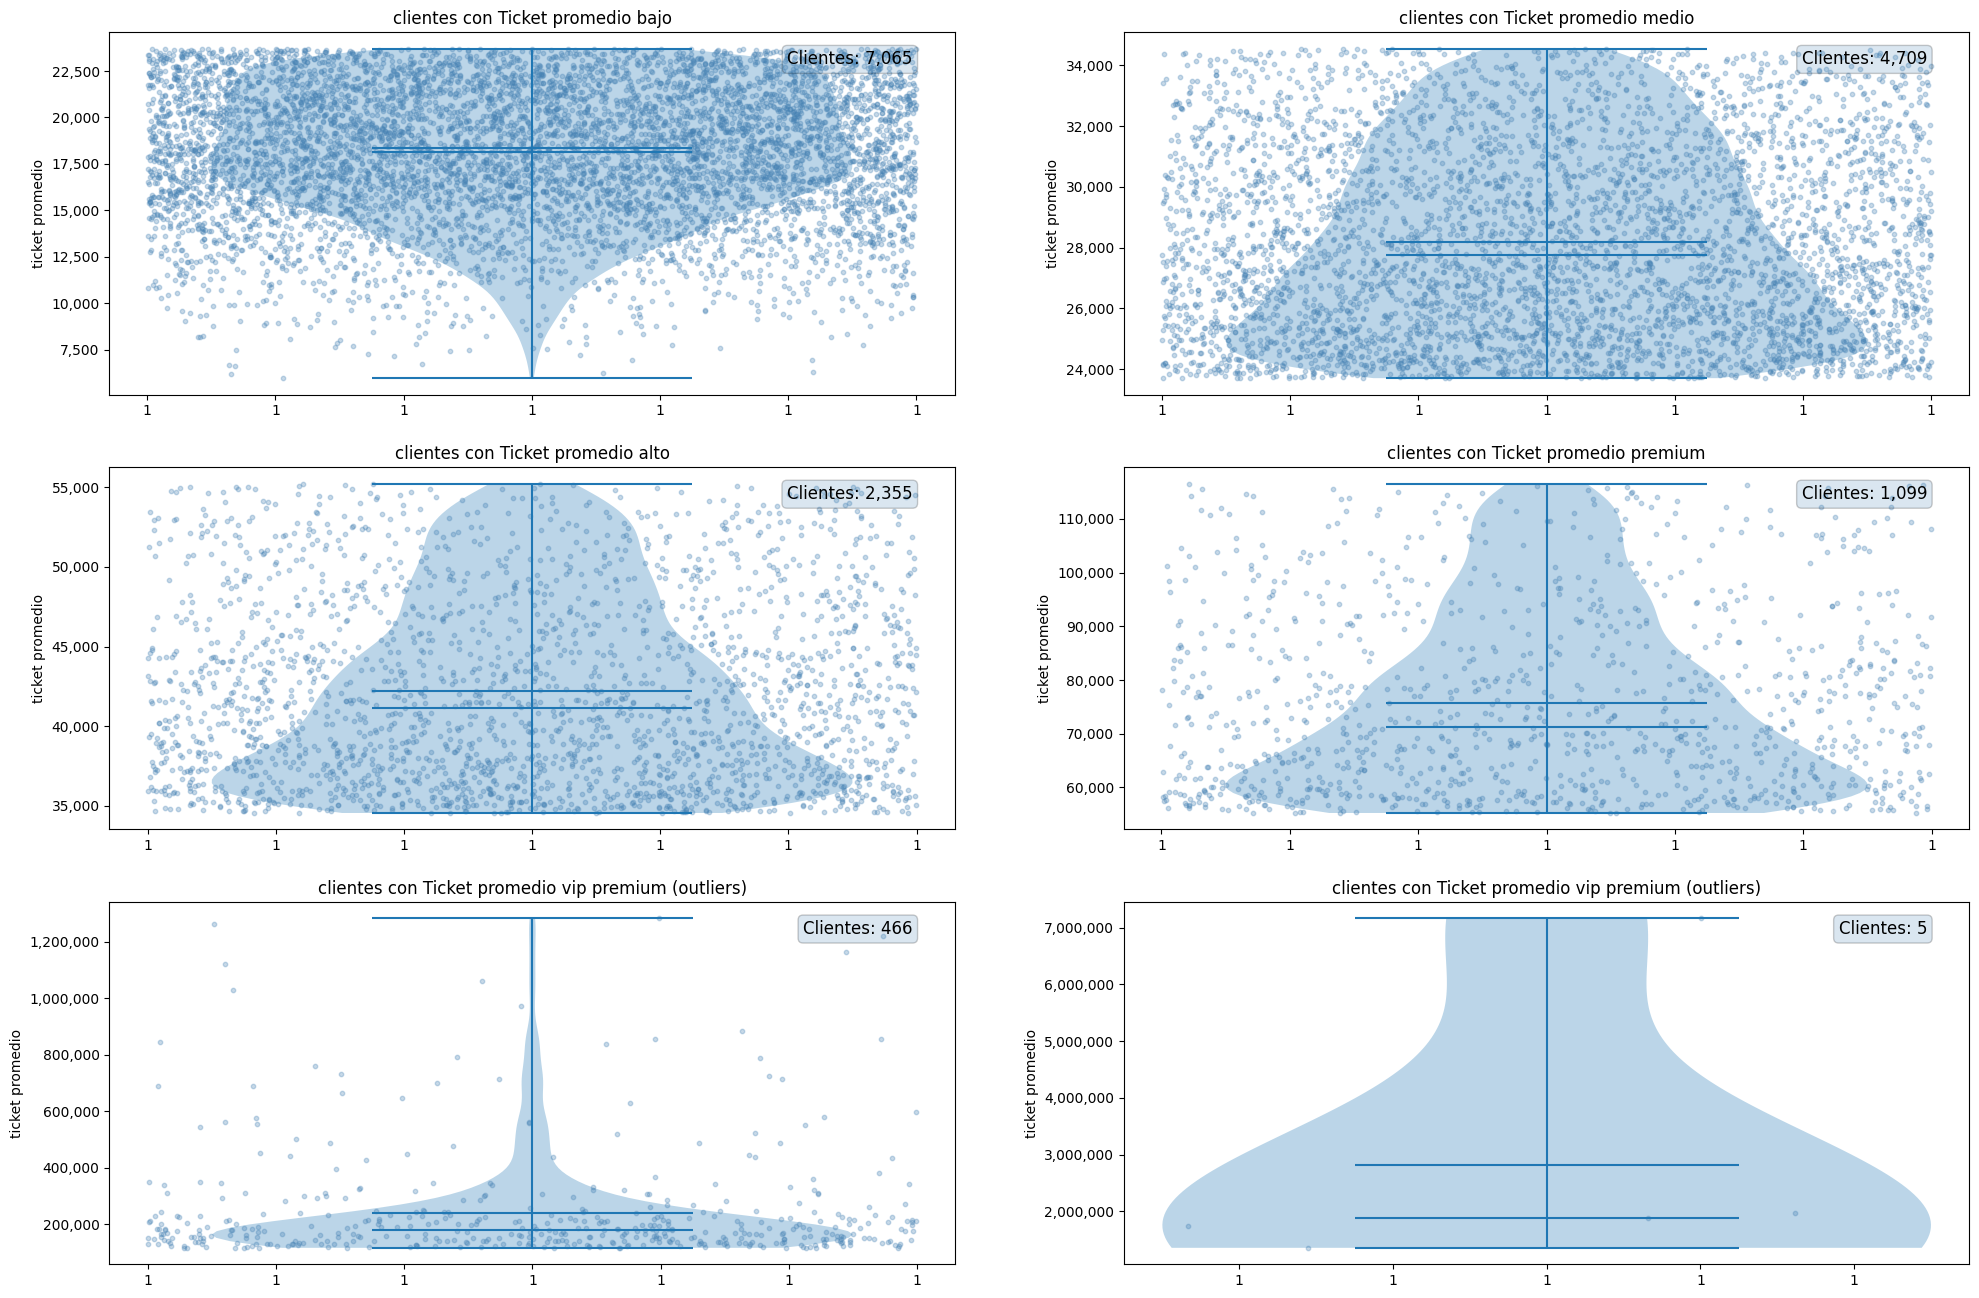

In [24]:
fig,([x1,x2],[x3,x4],[x5,x6]) = plt.subplots(3,2, figsize = (24,16))
#### Primer grafico
x1.set_title('clientes con Ticket promedio bajo')
x1.set_ylabel('ticket promedio')
x1.violinplot(df_bajo['ticket_promedio'], showmeans=True, showmedians=True)
x1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
x1.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
jitter = np.random.uniform(0.7, 1.3, size=len(df_bajo))
x1.scatter(jitter, 
            df_bajo['ticket_promedio'], 
            alpha=0.3, 
            s=10, 
            color='steelblue')
x1.text(0.95, 0.95, 
        f'Clientes: {len(df_bajo):,}', 
        transform=x1.transAxes,    # Para que use coordenadas relativas
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.2))

#### Segundo grafico
x2.set_title('clientes con Ticket promedio medio')
x2.set_ylabel('ticket promedio')
x2.violinplot(df_medio['ticket_promedio'], showmeans=True, showmedians=True)
x2.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
x2.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
jitter = np.random.uniform(0.7, 1.3, size=len(df_medio))
x2.scatter(jitter, 
            df_medio['ticket_promedio'], 
            alpha=0.3, 
            s=10, 
            color='steelblue')
x2.text(0.95, 0.95, 
        f'Clientes: {len(df_medio):,}', 
        transform=x2.transAxes,    # Para que use coordenadas relativas
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.2))
#### tercer grafico
x3.set_title('clientes con Ticket promedio alto')
x3.set_ylabel('ticket promedio')
x3.violinplot(df_alto['ticket_promedio'], showmeans=True, showmedians=True)
x3.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
x3.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
jitter = np.random.uniform(0.7, 1.3, size=len(df_alto))
x3.scatter(jitter, 
            df_alto['ticket_promedio'], 
            alpha=0.3, 
            s=10, 
            color='steelblue')
x3.text(0.95, 0.95, 
        f'Clientes: {len(df_alto):,}', 
        transform=x3.transAxes,    # Para que use coordenadas relativas
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.2))

#### Cuarto grafico
x4.set_title('clientes con Ticket promedio premium')
x4.set_ylabel('ticket promedio')
x4.violinplot(df_premium['ticket_promedio'], showmeans=True, showmedians=True)
x4.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
x4.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
jitter = np.random.uniform(0.7, 1.3, size=len(df_premium))
x4.scatter(jitter, 
            df_premium['ticket_promedio'], 
            alpha=0.3, 
            s=10, 
            color='steelblue')
x4.text(0.95, 0.95, 
        f'Clientes: {len(df_premium):,}', 
        transform=x4.transAxes,    # Para que use coordenadas relativas
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.2))
#### Quinto grafico

x5.set_title('clientes con Ticket promedio vip premium (outliers)')
x5.set_ylabel('ticket promedio')
x5.violinplot(df_vip_premium['ticket_promedio'], showmeans=True, showmedians=True)
x5.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
x5.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
jitter = np.random.uniform(0.7, 1.3, size=len(df_vip_premium))
x5.scatter(jitter, 
            df_vip_premium['ticket_promedio'], 
            alpha=0.3, 
            s=10, 
            color='steelblue')
x5.text(0.95, 0.95, 
        f'Clientes: {len(df_vip_premium):,}', 
        transform=x5.transAxes,    # Para que use coordenadas relativas
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.2))
####Sexto grafico
x6.set_title('clientes con Ticket promedio vip premium (outliers)')
x6.set_ylabel('ticket promedio')
x6.violinplot(df_outlier['ticket_promedio'], showmeans=True, showmedians=True)
x6.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
x6.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:,.0f}'))
jitter = np.random.uniform(0.7, 1.3, size=len(df_outlier))
x6.scatter(jitter, 
            df_outlier['ticket_promedio'], 
            alpha=0.3, 
            s=10, 
            color='steelblue')
x6.text(0.95, 0.95, 
        f'Clientes: {len(df_outlier):,}', 
        transform=x6.transAxes,    # Para que use coordenadas relativas
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.2))



Text(0, 0.5, 'ticket_promedio')

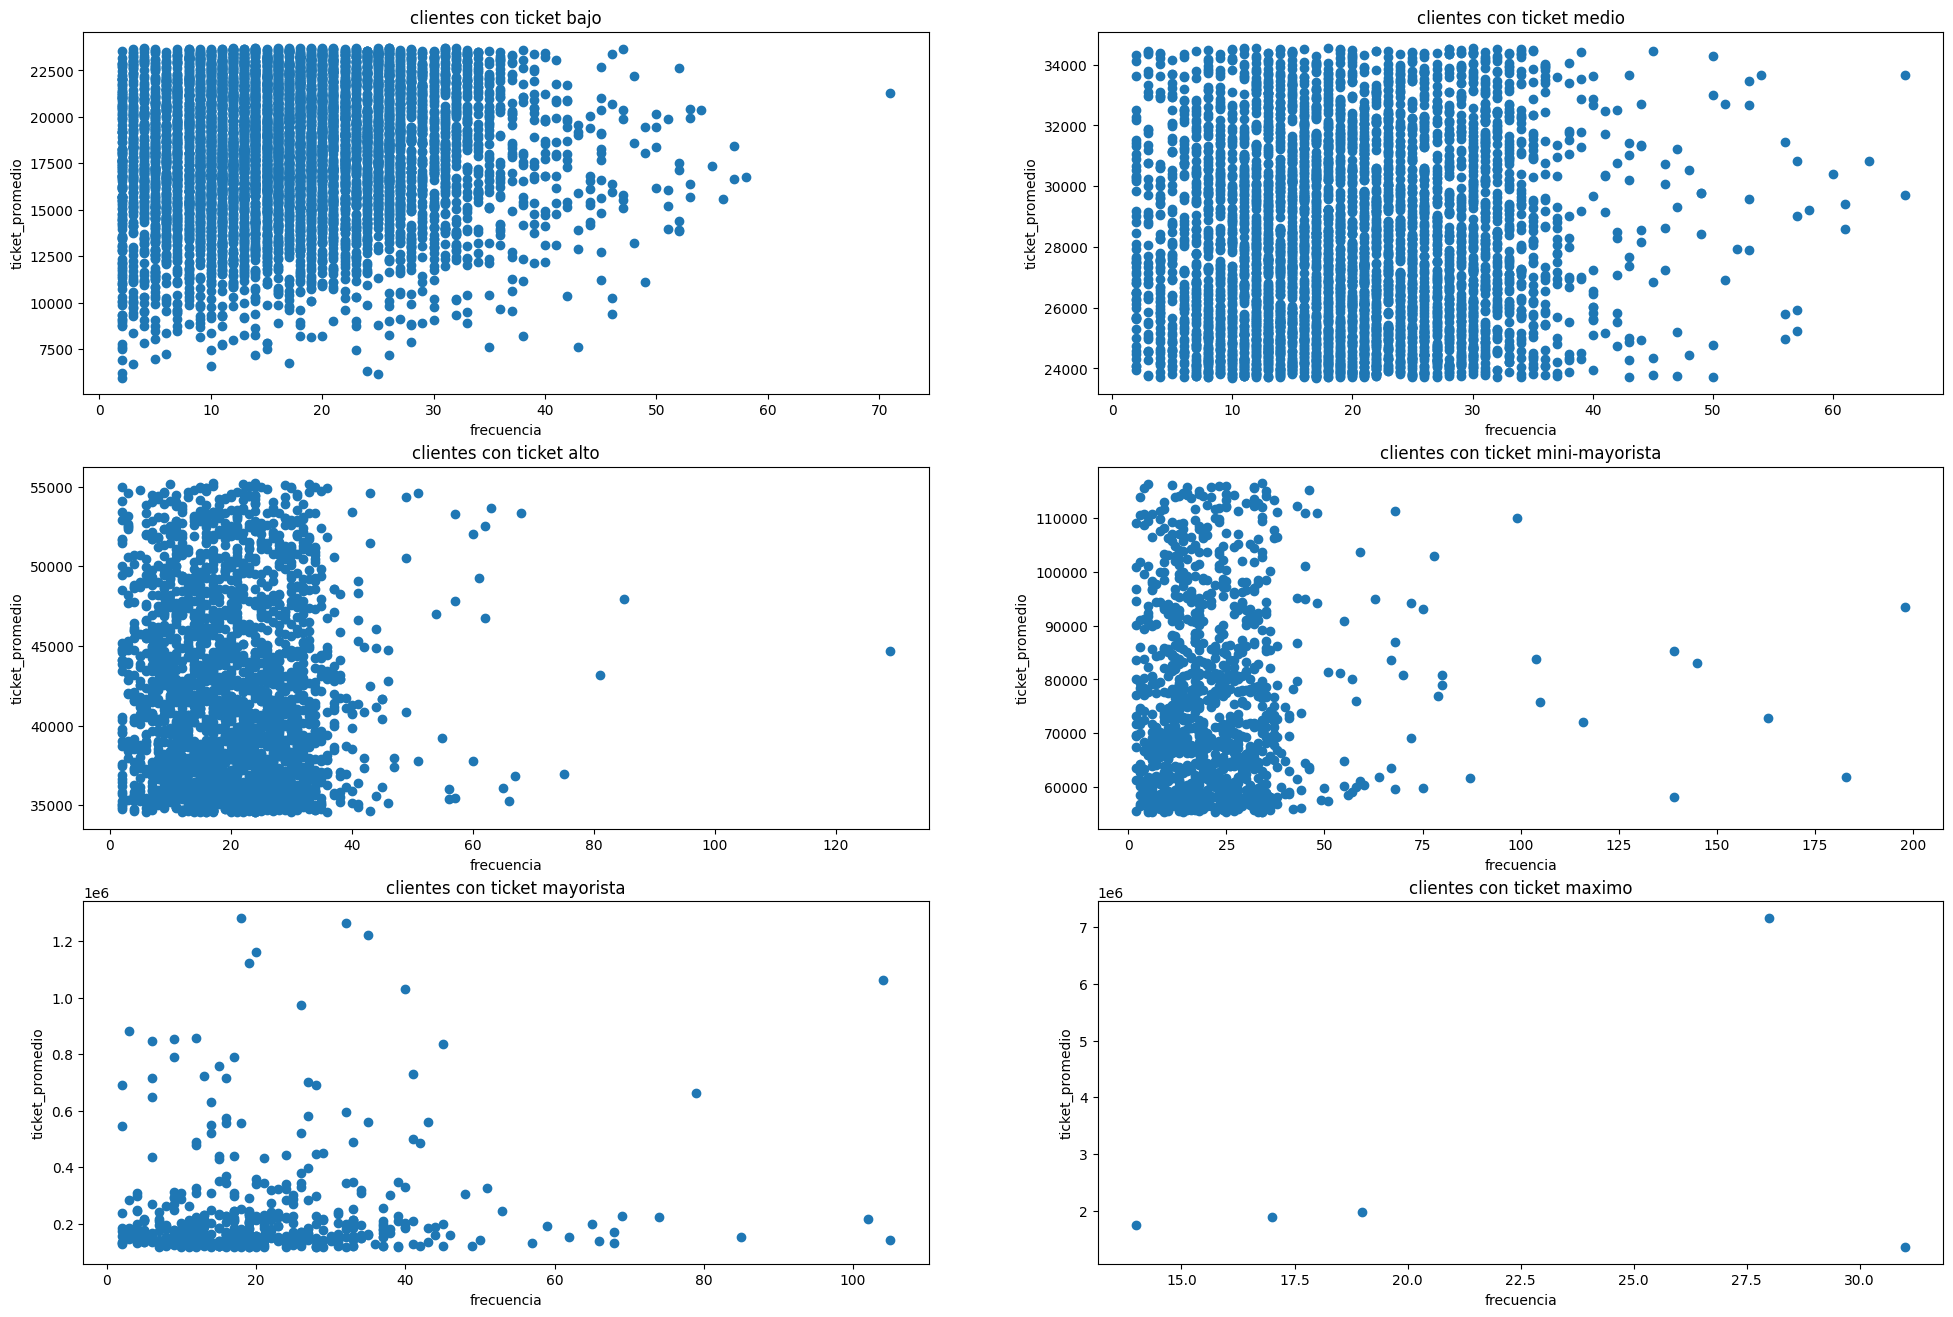

In [25]:
fig,([x1,x2],[x3,x4],[x5,x6]) = plt.subplots(3,2, figsize = (24,16))

x1.set_xlabel('frecuencia')
x1.set_ylabel('ticket_promedio')
x1.scatter(x=df_bajo['frecuencia'], y =df_bajo['ticket_promedio'] )
x1.set_title('clientes con ticket bajo')

x2.scatter(x=df_medio['frecuencia'], y =df_medio['ticket_promedio'] )
x2.set_title('clientes con ticket medio')
x2.set_xlabel('frecuencia')
x2.set_ylabel('ticket_promedio')

x3.scatter(x=df_alto['frecuencia'], y =df_alto['ticket_promedio'] )
x3.set_title('clientes con ticket alto')
x3.set_xlabel('frecuencia')
x3.set_ylabel('ticket_promedio')

x4.scatter(x=df_premium['frecuencia'], y =df_premium['ticket_promedio'] )
x4.set_title('clientes con ticket mini-mayorista')
x4.set_xlabel('frecuencia')
x4.set_ylabel('ticket_promedio')

x5.scatter(x=df_vip_premium['frecuencia'], y =df_vip_premium['ticket_promedio'] )
x5.set_title('clientes con ticket mayorista')
x5.set_xlabel('frecuencia')
x5.set_ylabel('ticket_promedio')

x6.scatter(x=df_outlier['frecuencia'], y =df_outlier['ticket_promedio'] )
x6.set_title('clientes con ticket maximo')
x6.set_xlabel('frecuencia')
x6.set_ylabel('ticket_promedio')

## Exportando segmentos

In [26]:
df_bajo.to_csv('../processed/bajo.csv', sep=';',index=False)
df_medio.to_csv('../processed/medio.csv', sep=';',index=False)
df_alto.to_csv('../processed/alto.csv', sep=';',index=False)
df_premium.to_csv('../processed/premium.csv', sep=';',index=False)
df_vip_premium.to_csv('../processed/vip_premium.csv', sep=';',index=False)
df_outlier.to_csv('../processed/outlier.csv', sep=';',index=False)
df_nuevos.to_csv('../processed/clientes_nuevos.csv', sep=';',index=False)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944178 entries, 0 to 944177
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   factura              944178 non-null  object        
 1   cliente              944178 non-null  int64         
 2   nombrecliente        944178 non-null  object        
 3   tipocliente          944178 non-null  object        
 4   fechafactura         944178 non-null  datetime64[ns]
 5   referencia           944178 non-null  object        
 6   nombrereferencia     944178 non-null  object        
 7   cantidad             944178 non-null  float64       
 8   preciounitario       944178 non-null  float64       
 9   costounitario        944178 non-null  float64       
 10  montoventa           944178 non-null  float64       
 11  montoventapesos      944178 non-null  float64       
 12  costoventapesos      944178 non-null  float64       
 13  valordescuento

### Exportando informacion de clientes nuevos

In [28]:
df_nuevos = pd.merge(df_nuevos[['cliente','recencia','linea_favorita','marca_favorita']], df[['cliente','montoventapesos','margenpesos','porcentajedescuento','nombrecliente']], on= 'cliente', how='inner')
df_nuevos.to_csv('../processed/clientes_nuevos.csv', sep=';',index=False)

In [29]:
df_nuevos.describe()

,cliente,recencia,montoventapesos,margenpesos,porcentajedescuento
count,970.00,970.00,970.00,970.00,970.00
mean,"588,348,660.88",31.37,"39,260.37","23,157.66",0.01
std,"494,567,607.93",23.07,"74,954.70","50,082.29",0.02
min,"3,236,456.00",1.00,891.00,204.00,0.00
25%,"43,686,202.00",15.00,"12,941.18","5,658.72",0.00
50%,"1,000,833,671.50",25.00,"22,184.88","12,548.36",0.00
75%,"1,038,546,110.00",51.00,"35,294.00","20,528.70",0.00
max,"1,237,690,386.00",81.00,"1,500,504.00","1,070,081.62",0.10


In [30]:
matriz=df.groupby('factura')['referencia'].apply(list)
indices = matriz.index.tolist()

In [31]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,association_rules

te = TransactionEncoder()
te_ary= te.fit(matriz).transform(matriz)
df_matriz = pd.DataFrame(te_ary, columns= te.columns_, index= indices)


In [32]:
mba =apriori(df_matriz, min_support=0.03, use_colnames=True)
mba['cantidad_productos'] = mba['itemsets'].apply(lambda x: len(x))
mba

,support,itemsets,cantidad_productos
0,0.05,(CPSCL),1
1,0.04,(RKACI3GR12),1
2,0.04,(RKLNSGX1),1
3,0.08,(SBLEDA6012WM10CLBLK),1
4,0.10,(SBLEDA607WM10CLBLK),1
5,0.09,(SBLEDA609WM10CLBLK),1
6,0.04,(SBLEDT730WMCLBLK),1
7,0.08,(SLBSLE),1
8,0.04,(SLJETT),1
9,0.04,(SLSSFL),1


In [33]:
reglas = association_rules(mba, metric='confidence', min_threshold=0.5)
reglas

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TRAALR6ALB2),(TRAAALR03ALB2),0.19,0.15,0.10,0.54,3.60,1.00,0.07,1.86,0.89,0.43,0.46,0.61
1,(TRAAALR03ALB2),(TRAALR6ALB2),0.15,0.19,0.10,0.68,3.60,1.00,0.07,2.53,0.85,0.43,0.60,0.61
2,(TRAAAR03EHDB2),(TRAALR6ALB2),0.06,0.19,0.03,0.53,2.83,1.00,0.02,1.74,0.69,0.14,0.43,0.35
3,(TRAAR6EHDB2),(TRAAAR03EHDB2),0.07,0.06,0.05,0.68,11.65,1.00,0.04,2.91,0.98,0.58,0.66,0.74
4,(TRAAAR03EHDB2),(TRAAR6EHDB2),0.06,0.07,0.05,0.80,11.65,1.00,0.04,4.55,0.97,0.58,0.78,0.74
5,(TRAAAR03EHDBLK),(TRAAR6EHDR1),0.31,0.36,0.20,0.65,1.83,1.00,0.09,1.86,0.65,0.43,0.46,0.61
6,(TRAAR6EHDR1),(TRAAAR03EHDBLK),0.36,0.31,0.20,0.56,1.83,1.00,0.09,1.58,0.71,0.43,0.37,0.61
7,(TRAAR6EHDB2),(TRAALR6ALB2),0.07,0.19,0.04,0.54,2.88,1.00,0.02,1.77,0.70,0.17,0.44,0.37
8,"(TRAAAR03EHDBLK, TRAALR6ALB2)",(TRAAR6EHDR1),0.04,0.36,0.03,0.76,2.12,1.00,0.02,2.66,0.55,0.09,0.62,0.43
9,"(TRAALR6ALB2, TRAAR6EHDR1)",(TRAAAR03EHDBLK),0.06,0.31,0.03,0.60,1.95,1.00,0.02,1.72,0.51,0.10,0.42,0.35


In [34]:
reglas.to_csv('../reglas/general.csv')